# Week 2 과제 실행: 보험 상담 컨시어지 (Stateful Consultation Agent)

## 추가된 것
- `compile(checkpointer=InMemorySaver())` — thread별로 대화 상태를 분리·복원
- `compile(interrupt_before=["tools"])` — 보험 정보 조회 직전 사용자 검토를 받기 위한 정적 인터럽트

## 도메인
1주차의 YouTube 학습 도메인을 보험 상담(상품·특약 조회)으로 갈아끼웠습니다. 그래프 골격(agent ↔ tools ReAct 루프)은 동일합니다.

## 시연 시나리오
1. **같은 thread + 맥락 누적** — `alice-001`로 4턴 대화. 두 번째 턴부터 이전 발화를 참조하는 질문 3개+를 던져 checkpointer가 메시지를 누적·복원하는지 확인.
2. **다른 thread + 격리** — `bob-001`이 동일한 맥락 의존 질문을 던졌을 때 빈 컨텍스트로 시작되는지 확인.
3. **state history** — `get_state_history`로 thread에 쌓인 스냅샷 개수를 확인.

In [1]:
import os, sys
sys.path.insert(0, '.')

from dotenv import load_dotenv
load_dotenv('../../../.env', override=True)

True

## 1. 그래프 구조

`agent ⇄ tools` ReAct 루프는 1주차와 동일. `tools` 노드 앞에 `__interrupt = before` 표시가 붙은 것이 Week 2의 시각적 차이.

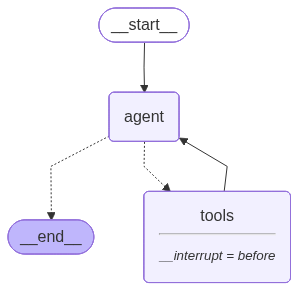

In [2]:
from IPython.display import Image, display
from graph import graph

display(Image(graph.get_graph().draw_mermaid_png()))

## 2. 시연 헬퍼

`stream_mode="updates"`로 노드별 변경분을 보고, `interrupt_before=["tools"]`로 멈춘 자리에서 사용자 검토 후 `stream(None, cfg)`로 재개합니다.

실제 서비스라면 이 자리에서 사용자에게 "`lookup_product("건강보험")`을 호출해도 될까요?"를 묻겠지만, 여기서는 시연 목적상 모든 도구 호출을 자동 승인합니다.

In [3]:
from langchain_core.messages import AIMessage, ToolMessage


def _print_chunk(chunk):
    """stream_mode='updates' chunk: {node: {messages: [...], ...}} 형태. '__interrupt__' 이벤트는 별도 출력에서 다루므로 건너뜀."""
    for node, update in chunk.items():
        if node == '__interrupt__':
            continue
        for msg in update.get('messages', []):
            if isinstance(msg, ToolMessage):
                print(f'  [{node}] tool_result: {msg.content[:400]}')
            elif isinstance(msg, AIMessage):
                if msg.tool_calls:
                    for tc in msg.tool_calls:
                        print(f'  [{node}] tool_call: {tc["name"]}({tc["args"]})')
                else:
                    print(f'  [{node}] AI: {msg.content[:400]}')


def consult(question, cfg):
    """질문 → interrupt → 사용자 검토(시뮬레이션) → resume 까지 한 turn 처리."""
    tid = cfg['configurable']['thread_id']
    print('=' * 72)
    print(f'[{tid}] Q: {question}')
    print('=' * 72)

    for chunk in graph.stream({'messages': [('human', question)]}, cfg, stream_mode='updates'):
        _print_chunk(chunk)

    while True:
        state = graph.get_state(cfg)
        if not state.next:
            break
        print(f'  ⏸  interrupt before {state.next} → 사용자 검토 후 승인 → resume')
        for chunk in graph.stream(None, cfg, stream_mode='updates'):
            _print_chunk(chunk)

## 3. 시나리오 ① — 같은 thread + 맥락 누적

`thread_id="alice-001"`로 4턴 대화. 두 번째 턴부터 **이전 발화를 명시적으로 참조**하는 맥락 의존 질문 3개를 던져, checkpointer가 메시지를 누적해서 LLM에 전달하는지 확인합니다.

- turn 1 (첫 질문): 가입자 프로필 공유
- turn 2 (맥락 활용 ①): 방금 말한 조건에서 ...
- turn 3 (맥락 활용 ②): 그 상품에 ...
- turn 4 (맥락 활용 ③): 내 또래에서 ...

In [4]:
cfg_alice = {'configurable': {'thread_id': 'alice-001'}}

consult('저는 30대 직장인이고 가족력이 있어요. 어떤 보험을 우선 살펴봐야 할까요?', cfg_alice)

[alice-001] Q: 저는 30대 직장인이고 가족력이 있어요. 어떤 보험을 우선 살펴봐야 할까요?


  [agent] tool_call: lookup_product({'name': '건강보험'})
  ⏸  interrupt before ('tools',) → 사용자 검토 후 승인 → resume


  [tools] tool_result: {"name": "건강보험", "overview": "질병이나 상해로 인해 발생하는 의료비 부담과 치료 관련 위험을 보장하는 보험입니다. 입원, 수술, 통원 치료 등 건강 관련 비용을 보완하는 데 목적이 있습니다.", "main_coverage": ["질병·상해로 인한 입원비 보장", "수술비 보장", "통원 및 외래 치료비 보장", "진단 관련 비용 보장", "각종 의료비 부담 보완"]}


  [agent] tool_call: lookup_product({'name': '암보험'})
  ⏸  interrupt before ('tools',) → 사용자 검토 후 승인 → resume


  [tools] tool_result: {"name": "암보험", "overview": "암 진단 및 치료 과정에서 발생하는 경제적 부담을 줄이기 위해 암 관련 위험을 보장하는 보험입니다. 주로 암 진단비, 치료비, 수술비 등 암으로 인한 비용을 지원합니다.", "main_coverage": ["암 진단비 지급", "암 치료비 보장", "암 수술비 보장", "입원 및 통원 치료비 보장", "재발·전이암 관련 보장"]}


  [agent] tool_call: summarize_coverage({'product_name': '건강보험', 'user_interests': ['가족력', '30대 직장인', '입원', '수술', '통원', '진단비']})
  ⏸  interrupt before ('tools',) → 사용자 검토 후 승인 → resume


  [tools] tool_result: {"summary": "이 건강보험은 가족력으로 걱정되는 질병에 대비해 진단 시 필요한 진단비를 중심으로, 입원·수술·통원 치료까지 폭넓게 보장하는 방향으로 활용하기 좋습니다. 특히 30대 직장인이 자주 부담하게 되는 예상치 못한 질병·상해 치료비를 입원비, 수술비, 통원비로 나눠 대비할 수 있어 실질적인 의료비 부담 완화에 도움이 됩니다. 다만 상품별 보장 범위와 한도는 다를 수 있어, 가족력 있는 질환이 실제로 특약 대상에 포함되는지 확인이 필요합니다.", "relevant_riders": ["질병진단비특약", "입원일당특약", "수술비특약", "통원치료특약"]}


  [agent] AI: {
  "kind": "answer",
  "message": "30대 직장인이고 가족력이 있다면, 우선 아래 순서로 살펴보는 걸 추천드려요.\n\n1) 건강보험\n- 질병·상해로 인한 입원비, 수술비, 통원치료비를 폭넓게 보완하기 좋습니다.\n- 가족력으로 걱정되는 질환이 있다면 진단비 특약이 있는지 꼭 확인하세요.\n\n2) 암보험\n- 가족력과 가장 많이 연결해서 보는 대표 상품입니다.\n- 암 진단비, 치료비, 수술비, 재발·전이 보장까지 확인하면 좋습니다.\n\n우선 체크할 포인트\n- 가족력 있는 질환이 보장 대상인지\n- 진단비가 충분한지\n- 입원/수술/통원 보장이 실사용에 맞는지\n- 특약으로 어떤 질환을 추가할 수 있는지\n\n참고로 건강보험 쪽에서는 보통 아래 특약을 많이 함께 봅니다.\


In [5]:
consult('방금 말한 조건에서 암보험은 어떤가요?', cfg_alice)

[alice-001] Q: 방금 말한 조건에서 암보험은 어떤가요?


  [agent] tool_call: summarize_coverage({'product_name': '암보험', 'user_interests': ['30대 직장인', '가족력', '암 진단비', '암 치료비', '암 수술비', '재발·전이 보장']})
  ⏸  interrupt before ('tools',) → 사용자 검토 후 승인 → resume


  [tools] tool_result: {"summary": "이 암보험은 30대 직장인이 가족력 때문에 걱정하는 암 위험에 대비해, 암 진단 시 진단비를 중심으로 초기 치료 자금을 마련하는 데 유용한 상품입니다. 암 치료비와 암 수술비 보장이 포함되어 있거나 특약으로 추가할 수 있다면, 수술·항암치료·입원 등 실제 치료 과정의 부담을 줄이는 데 도움이 됩니다. 또한 재발·전이 보장 특약이 있다면 첫 진단 이후 다시 암이 발견되거나 다른 부위로 퍼졌을 때도 보장을 이어갈 수 있어 장기 대비에 적합합니다.", "relevant_riders": []}


  [agent] AI: {
  "kind": "answer",
  "message": "방금 말한 조건이라면 암보험은 꽤 우선순위가 높아요.\n\n왜 괜찮냐면:\n- 30대라도 가족력이 있으면 암 진단비를 미리 준비해두는 게 도움이 됩니다.\n- 암은 치료 기간이 길어질 수 있어서 진단비 + 치료비 + 수술비 구성이 중요합니다.\n- 재발·전이까지 챙기면 장기 대비에 더 유리합니다.\n\n특히 확인할 점\n- 암 진단비가 충분한지\n- 항암치료/수술/입원 보장이 포함되는지\n- 재발·전이암 보장이 있는지\n- 유사암 보장 범위와 감액 조건이 있는지\n- 가족력 있는 암종이 보장 대상인지\n\n정리하면, 지금 조건에서는\n1) 암 진단비 중심 암보험\n2) 치료·수술·재발/전이 보장까지 확장\n이런 순서로 보시면 좋습니다.\n\n원


In [6]:
consult('그 암보험에 어떤 특약을 붙이는 게 좋을까요?', cfg_alice)

[alice-001] Q: 그 암보험에 어떤 특약을 붙이는 게 좋을까요?


  [agent] tool_call: lookup_rider({'name': '암 진단비 특약'})
  ⏸  interrupt before ('tools',) → 사용자 검토 후 승인 → resume


  [tools] tool_result: {"name": "암 진단비 특약", "coverage": "암으로 진단 확정되었을 때 약정한 진단비를 지급하는 특약입니다. 일반적으로 최초 1회 진단 시 가입금액을 정액으로 보장하며, 진단금은 치료비나 생활비 등으로 사용할 수 있습니다.", "exclusions": ["보장개시일 이전에 이미 진단받았거나 그 시점에 의심·검사 중이던 암은 보장 제외될 수 있습니다.", "일반암과 유사해 보여도 유사암, 소액암은 지급금액이 다르거나 별도 한도로 제한될 수 있습니다.", "약관상 보장하지 않는 암의 범위, 면책기간, 재진단 여부 조건을 반드시 확인해야 합니다."], "renewable": false}


  [agent] tool_call: lookup_rider({'name': '암 치료비 특약'})
  [agent] tool_call: lookup_rider({'name': '암 수술비 특약'})
  [agent] tool_call: lookup_rider({'name': '재발·전이암 특약'})
  [agent] tool_call: lookup_rider({'name': '항암치료 특약'})
  ⏸  interrupt before ('tools',) → 사용자 검토 후 승인 → resume


  [tools] tool_result: {"name": "암 치료비 특약", "coverage": "암으로 진단되거나 암 치료가 필요해 약관상 보장 대상 치료를 받은 경우, 입원·수술·항암약물·항암방사선 등 암 치료에 드는 비용을 특약 한도 내에서 보장합니다. 상품에 따라 진단 후 직접 치료비뿐 아니라 치료와 관련된 입원비, 수술비, 통원치료비가 포함될 수 있습니다.", "exclusions": ["약관상 보장개시일 이전에 이미 진단·발생한 암은 제외될 수 있습니다.", "고의·자해, 전쟁, 핵 관련 손해 등 일반 면책사유는 보장되지 않습니다.", "피부암, 갑상선암 등 일부 경계성·소액암은 보장 범위가 다를 수 있습니다.", "실손형이 아닌 정액형 특약이면 실제 지출액과 무관하게 한도 내에서만 지급됩니다."], "renewable": true}
  [tools] tool_result: {"name": "암 수술비 특약", "coverage": "암으로 진단받은 뒤 해당 암의 치료를 직접적인 목적으로 수술을 받았을 때, 약정한 수술비를 보장하는 특약입니다. 보통 암의 절제·제거·봉합 등 수술행위에 대해 정액으로 지급되며, 약관상 보장개시일과 지급사유를 충족해야 합니다.", "exclusions": ["보장개시일 이전에 이미 진단·발생한 암은 제외될 수 있습니다.", "원인이 암이 아닌 일반 질병이나 상해 수술은 보장되지 않습니다.", "의학적으로 필요하지 않거나 미용·성형 목적의 수술은 제외됩니다.", "약관에서 정한 면책기간 중 진단·수술한 경우 지급이 제한될 수 있습니다."], "renewable": true}
  [tools] tool_result: {"name": "재발·전이암 특약", "coverage": "암 진단 후 치료가 종료되거나 일정 기간 경과한 뒤, 같은 암의 재발 또는 다른 부위로의 전이로 인해 추가 진단·치료가 필요한 경우 관련 보험금 지급을 보장하는 특약입니다. 통상 최초 암 진단 이후 발생한 재발암·전이암에 대해 약정한 조건을 충족

  [agent] AI: {
  "kind": "answer",
  "message": "방금 조건(30대 직장인 + 가족력)이라면 암보험에 붙일 특약은 아래 순서로 많이 봅니다.\n\n1) 암 진단비 특약\n- 암 진단 시 가장 먼저 필요한 목돈 역할을 합니다.\n- 치료비뿐 아니라 생활비, 간병비, 소득 공백 대응에도 유용해요.\n\n2) 항암치료 특약\n- 항암약물치료, 항암방사선치료 같은 실제 치료 부담을 보완합니다.\n- 진단비만으로 부족할 수 있는 치료비를 메우는 용도로 좋습니다.\n\n3) 암 수술비 특약\n- 암 수술이 필요할 때 수술비를 정액으로 받을 수 있습니다.\n- 수술 가능성이 걱정되면 같이 보는 편이 좋습니다.\n\n4) 재발·전이암 특약\n- 한 번 치료 후 끝이 아니라, 재발·전이까지 장기 대비하려면 중


In [7]:
consult('제 또래에서 가장 주의해야 할 면책 사항은 무엇인가요?', cfg_alice)

[alice-001] Q: 제 또래에서 가장 주의해야 할 면책 사항은 무엇인가요?


  [agent] AI: {
  "kind": "chat",
  "message": "‘제 또래’가 30대 직장인을 뜻하는 거라면, 암보험에서 특히 자주 놓치는 면책은 **보장개시일 이전에 이미 있던 증상/검사 중이던 질환**, **면책기간 중 진단**, **유사암·소액암의 보장 축소**, **재발·전이 조건 미충족**이에요. 다만 상품마다 다르니, 원하시면 제가 30대 기준으로 핵심 면책만 3줄로 더 정리해드릴게요.",
  "referenced_products": [],
  "referenced_riders": []
}


## 4. 시나리오 ② — 다른 thread + 격리

`thread_id="bob-001"`은 이전 대화를 본 적이 없습니다. alice가 했던 **맥락 의존 질문**을 그대로 던지면 "어떤 조건인지"를 되묻거나 일반론을 답해야 정상.

같은 그래프·같은 checkpointer라도 `thread_id`만 다르면 완전히 다른 대화로 분리된다는 점을 보여줍니다.

In [8]:
cfg_bob = {'configurable': {'thread_id': 'bob-001'}}

consult('방금 말한 조건에서 암보험은 어떤가요?', cfg_bob)

[bob-001] Q: 방금 말한 조건에서 암보험은 어떤가요?


  [agent] AI: {
  "kind": "chat",
  "message": "방금 말한 조건을 제가 확인할 수 없어서, 암보험이 어떤지 바로 판단하긴 어려워요. 나이, 성별, 가입 목적(진단비 중심/치료비 중심), 현재 가입한 보험 여부를 알려주시면 그 조건에 맞춰 비교해서 말씀드릴게요.",
  "referenced_products": [],
  "referenced_riders": []
}


## 5. 시나리오 ③ — `get_state_history`로 thread 상태 확인

thread별로 checkpointer가 쌓은 스냅샷 개수와 누적 메시지 수를 비교.

In [23]:
hist_alice = list(graph.get_state_history(cfg_alice))
hist_bob = list(graph.get_state_history(cfg_bob))

print(hist_alice)
print(hist_bob)
print(f'alice-001 스냅샷 개수: {len(hist_alice)}')
print(f'alice-001 누적 메시지 개수: {len(hist_alice[0].values["messages"])}')
print()
print(f'bob-001   스냅샷 개수: {len(hist_bob)}')
print(f'bob-001   누적 메시지 개수: {len(hist_bob[0].values["messages"])}')

[StateSnapshot(values={'messages': [HumanMessage(content='저는 30대 직장인이고 가족력이 있어요. 어떤 보험을 우선 살펴봐야 할까요?', additional_kwargs={}, response_metadata={}, id='3f459afb-aade-48d3-8157-0f19c2a81705'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 50, 'prompt_tokens': 609, 'total_tokens': 659, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-DgZM9G9kv9BBXQBIh7h13aJI3hkI0', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019e36ee-70ea-7180-a56e-7d7afd4e73dc-0', tool_calls=[{'name': 'lookup_product', 'args': {'name': '건강보험'}, 'id': 'call_ektpbx3HiBEXDXqMwByZlfsR', 'type': 'tool_call'}, {'name': 'lookup_product', 'args': {'nam